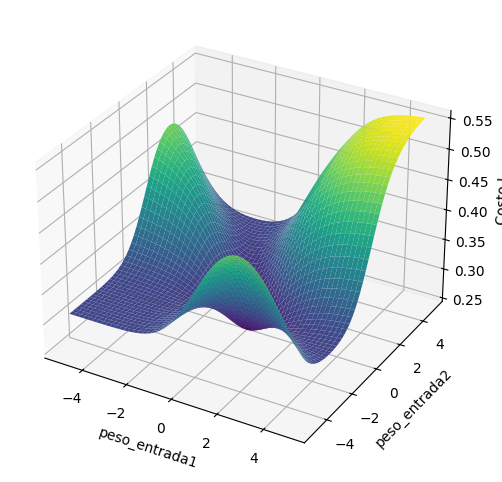

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# Datos de entrada (compuerta AND)
entradas = np.array([[0,0],[0,1],[1,0],[1,1]])
salidas = np.array([0,0,0,1])


# Función sigmoide
def sigmoide(valor):
    return 1 / (1 + np.exp(-valor))


# Predicción
def predecir(entradas, peso_entrada1, peso_entrada2, sesgo):
    linear_combination = peso_entrada1*entradas[:,0] + peso_entrada2*entradas[:,1] + sesgo
    return sigmoide(linear_combination)


# Función de costo
def funcion_costo(peso_entrada1, peso_entrada2, entradas, salidas, sesgo):
    predicciones = predecir(entradas, peso_entrada1, peso_entrada2, sesgo)
    return np.mean((salidas - predicciones)**2)


# Rango de valores
valores_peso1 = np.linspace(-5, 5, 50)
valores_peso2 = np.linspace(-5, 5, 50)
Peso1_grid, Peso2_grid = np.meshgrid(valores_peso1, valores_peso2)
Costo = np.zeros_like(Peso1_grid)


# Calcular costo en cada punto
sesgo = 0
for i in range(Peso1_grid.shape[0]):
    for j in range(Peso1_grid.shape[1]):
        Costo[i,j] = funcion_costo(Peso1_grid[i,j], Peso2_grid[i,j], entradas, salidas, sesgo)


# Graficar superficie 3D
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Peso1_grid, Peso2_grid, Costo, cmap='viridis')


ax.set_xlabel('peso_entrada1')
ax.set_ylabel('peso_entrada2')
ax.set_zlabel('Costo J')
plt.show()